# City Creation
This notebook created and visualises the different cities which will be used in the simulations.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from utils.city_metrics import CityCreation

# Creating the grid city 
All the graphs are based off an initial 6x8 grid layout which has the same start and exit positions. Each city then has edges removed to make the layout more bottlenecked.

In [4]:
import networkx as nx
import copy 
import pandas as pd

In [5]:
G = nx.grid_2d_graph(6, 9)
mapping = {(col, row): f"T{row * 6 + col}" for col, row in G.nodes()}

# Adding exits
mapping[(0, 8)] = 'E1'
mapping[(5, 8)] = 'E2'
mapping[(0, 0)] = 'E3'
mapping[(5, 0)] = 'E4'

# Adding starts
mapping[(3, 6)] = 'S1'
mapping[(4, 5)] = 'S2'
mapping[(1, 5)] = 'S3'
mapping[(2, 2)] = 'S4'

pos = {mapping[(x, y)]: (x, y) for x, y in G.nodes()}
G = nx.relabel_nodes(G, mapping)

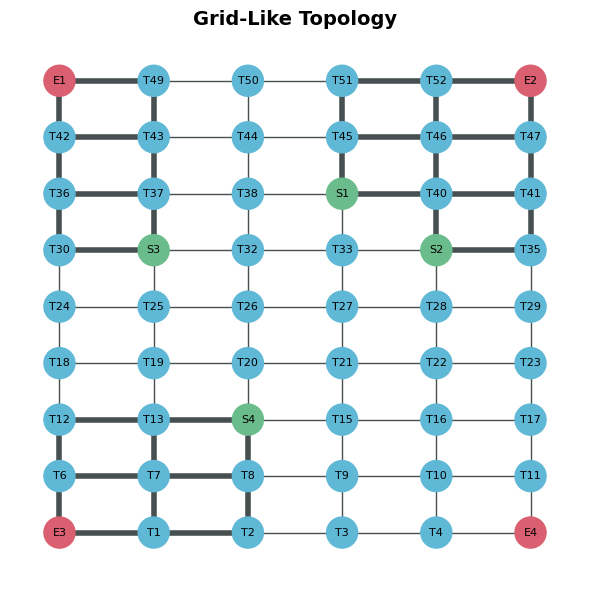

Avg Path Length     → 6.5
Max Betweeness      → 0.00122
Edge Density        → 0.065
Critical Edge       → ('E3', 'T6') (0.000893)


In [6]:
grid = CityCreation(
    G=G, city_name='Grid-Like Topology'
)
grid_metrics = grid.calculate_city_metrics()
grid.plot_city(
    save=True, pos=pos, show_paths=True
)
grid.save_graph_pickle()

Notes on the grid city:
* Matches traditional cities such as New York with grid like network of streets.
* There is an under used exit.
* There are lots of open pathways, I'd expect the genetic algorithm to use a range of these to avoid congestion.


## Creating the moderate city
This city will remove some edges to create bottle neck areas.

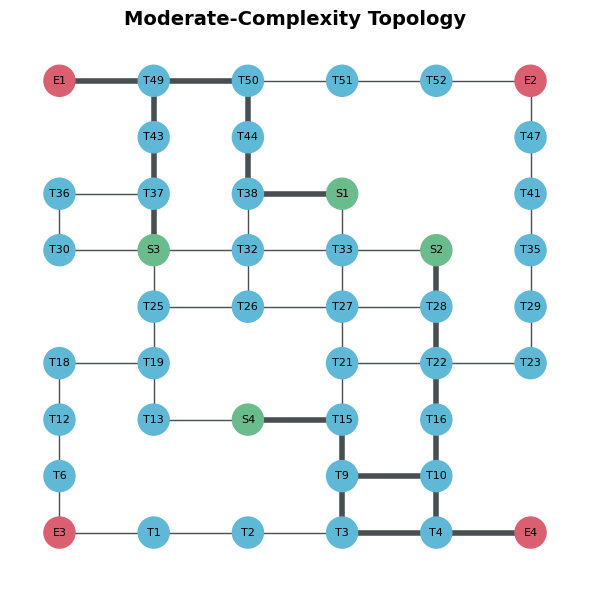

Avg Path Length     → 7.0
Max Betweeness      → 0.00249
Edge Density        → 0.0581
Critical Edge       → ('E1', 'T49') (0.00211)


In [7]:
G_moderate = copy.deepcopy(G)
pos_moderate = copy.deepcopy(pos)

moderate_nodes_to_remove = [
    "T42", "T24",
    "T7",
    "T20", "T8",
    "T45",
    "T46", "T40",
    "T11", "T17"
]
G_moderate.remove_nodes_from(moderate_nodes_to_remove)
for node in moderate_nodes_to_remove:
    pos_moderate.pop(node)

G_moderate.remove_edges_from([
    ('T43', 'T44'), ('T37', 'T38'), ('T12', 'T13'),
    ('T16', 'T17'), ('T15', 'T16'),
    ('S2', 'T35'), ('T28', 'T29')
])


moderate = CityCreation(
    G=G_moderate, city_name='Moderate-Complexity Topology'
)
moderate_metrics = moderate.calculate_city_metrics()
moderate.plot_city(
    save=True, pos=pos_moderate, show_paths=True
)
moderate.save_graph_pickle()

Notes on the moderate city:
* Again this city has under utilised exits
* The start nodes have overlapping exits but only with one other start.

## Bottlenecked City
This city should have key nodes which are essential for an agent to go from a start node to an exit node.

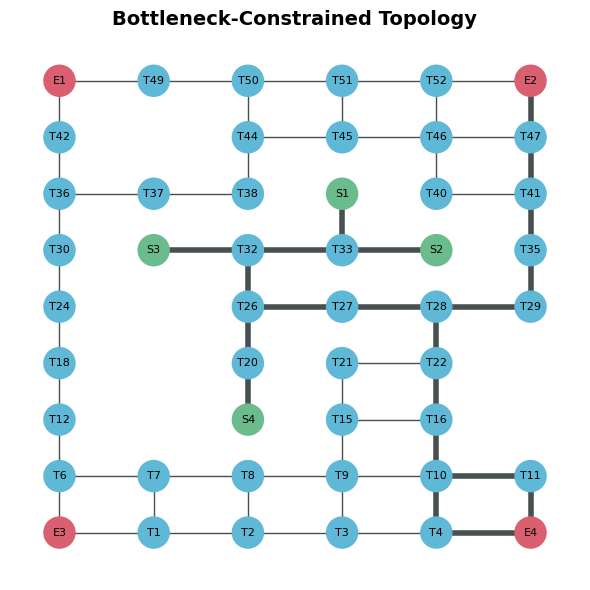

Avg Path Length     → 11.5
Max Betweeness      → 0.0074
Edge Density        → 0.0532
Critical Edge       → ('T26', 'T27') (0.00709)


In [8]:
G_bottleneck = copy.deepcopy(G)
pos_bottleneck = copy.deepcopy(pos)

bottleneck_nodes_to_remove = [
    "T23",
    "T25", "T19", "T13", "T17", "T43"
]
G_bottleneck.remove_nodes_from(bottleneck_nodes_to_remove)
for node in bottleneck_nodes_to_remove:
    pos_bottleneck.pop(node)

G_bottleneck.remove_edges_from([
    # START NODES
    ("S1", "T45"), ("S1", "T38"), ("S1", "T40"),
    ("S2", "T40"), ("S2", "T35"), ("S2", "T28"),
    ("S3", "T37"), ("S3", "T30"), ("S3", "T25"),
    ("S4", "T13"), ("S4", "T8"), ("S4", "T15"),
    # SURROUNDING BOTTLENECK NODES
    ("T32", "T38"), ("T25", "T26"), ("T20", "T19"),
    ("T20", "T21"), ("T27", "T21"), ("T33", "T27"),
    # ("T22", "T16")
])

bottleneck = CityCreation(
    G=G_bottleneck, city_name='Bottleneck-Constrained Topology'
)
bottleneck_metrics = bottleneck.calculate_city_metrics()

bottleneck.plot_city(
    save=True, pos=pos_bottleneck, show_paths=True
)
bottleneck.save_graph_pickle()

Notes on bottleneck city:
* This situation is meant to represent the scenario where there is only one exit from a building or something - it is to better understand how the agents fan out after the initial bottleneck.

## Metrics
How can I now confirm other than visually that these cities represent different situations?

### Metrics Used:
* Average Path Length - number of nodes the agent needs to pass through to reach an exit. The longer the path the higher chance of congestion. 
* Maximum Betweeness - finds the most used node in the network for shortest paths between any nodes. The higher this value the more likely a bottleneck is to occur on an exit route.
* Edge Density - ratio of actual edges to maximum possible edges in the graph. Although these numebrs will be small - expect to see the grid city metric smaller than the others due to the number of connections.
* Critical Edge Load - finds the edge which is on the highest proportion of shortest paths. This can be understood as a percentage - so 0.3 would mean 30% of shortest paths use this node.

In [9]:
metrics = {'city': ['grid', 'moderate', 'bottleneck']}
for metric in grid_metrics.keys():
    if metric == 'critical_edge':
        metrics[metric] = [grid_metrics[metric][1], moderate_metrics[metric][1], bottleneck_metrics[metric][1]]
    else:
        metrics[metric] = [grid_metrics[metric], moderate_metrics[metric], bottleneck_metrics[metric]]

metrics_df = pd.DataFrame(metrics)
metrics_df 

,city,mean_path_length,max_betweeness,edge_density,critical_edge
0,grid,6.5,0.001220,0.064990,0.000893
1,moderate,7.0,0.002492,0.058140,0.002114
2,bottleneck,11.5,0.007401,0.053191,0.007092


All metrics increase from the grid city (most flexibility and option choice for paths) to the bottleneck (limited exit path options), meaning the cities are quantifiably different.